## To start with, manually matching glaciers to one basin of interest, downloaded the basin data (shp, Q, precip, etc) from CAMELS. 

In [1]:
"""
Cell A: Basin-level glacier analysis using COD_CUEN mapping
Subsets existing cluster NetCDF outputs by BNA basin code
Computes MB, volume loss, and melt timeseries per basin
"""

import numpy as np
import pandas as pd
import xarray as xr
import os

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH  = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'
CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS'

ICE_DENSITY   = 900
WATER_DENSITY = 1000

# NetCDF suffix per cluster
NC_SUFFIX = {
    'OT3': 'run_output_2000_2019_hydro_TC_OT3.nc',
    'DA1': 'run_output_2000_2019_hydro_TC_DA1.nc',
    'DA2': 'run_output_2000_2019_hydro_TC_DA2.nc',
    'DA3': 'run_output_2000_2019_hydro_TC_DA3.nc',
    'WA1': 'run_output_2000_2019_hydro_TC_WA1.nc',
    'WA2': 'run_output_2000_2019_hydro_TC_WA2.nc',
    'WA3': 'run_output_2000_2019_hydro_TC_WA3.nc',
    'WA4': 'run_output_2000_2019_hydro_TC_WA4.nc',
    'WA5': 'run_output_2000_2019_hydro_TC_WA5.nc',
    'WA6': 'run_output_2000_2019_hydro_TC_WA6.nc',
}

# ── Load RGI mapping ───────────────────────────────────────────────────────
rgi = pd.read_csv(RGI_PATH)

# Normalize COD_CUEN to integer for consistent matching
rgi['COD_CUEN'] = rgi['COD_CUEN'].astype(str).str.lstrip('0')
rgi['COD_CUEN'] = pd.to_numeric(rgi['COD_CUEN'], errors='coerce').astype('Int64')

print(f'Total glaciers in RGI: {len(rgi)}')
print(f'Unique BNA basins:     {rgi["COD_CUEN"].nunique()}')
print(f'Clusters:              {rgi["Cluster"].unique().tolist()}')

# ── Load all cluster NetCDFs once ─────────────────────────────────────────
print('\nLoading cluster NetCDFs...')
nc_datasets = {}
for cluster, fname in NC_SUFFIX.items():
    nc_path = os.path.join(BASE_PATH, cluster, fname)
    if os.path.exists(nc_path):
        nc_datasets[cluster] = xr.open_dataset(nc_path)
        print(f'  ✓ {cluster}: {len(nc_datasets[cluster].rgi_id)} glaciers')
    else:
        print(f'  ✗ {cluster}: file not found — {nc_path}')

Total glaciers in RGI: 13246
Unique BNA basins:     45
Clusters:              ['WA4', 'WA6', 'WA3', 'WA5', 'WA2', 'WA1', 'DA3', 'DA2', 'DA1', 'OT3']

Loading cluster NetCDFs...
  ✓ OT3: 34 glaciers
  ✓ DA1: 422 glaciers
  ✓ DA2: 200 glaciers
  ✓ DA3: 410 glaciers
  ✓ WA1: 678 glaciers
  ✓ WA2: 2924 glaciers
  ✓ WA3: 447 glaciers
  ✓ WA4: 4749 glaciers
  ✓ WA5: 711 glaciers
  ✓ WA6: 2671 glaciers


In [8]:
"""
Cell B: Define basin-level extraction function
Computes annual MB, volume loss, and monthly melt for a given BNA basin code
"""

def extract_basin_outputs(basin_code, rgi_df, nc_datasets):
    """
    Extract glacier outputs for a single BNA basin from cluster NetCDFs.
    
    Parameters
    ----------
    basin_code : int
        BNA basin code (e.g. 94 for Río Toltén)
    rgi_df : pd.DataFrame
        RGI_BNA_Clusters.csv with COD_CUEN and Cluster columns
    nc_datasets : dict
        Loaded xarray datasets keyed by cluster name

    Returns
    -------
    dict with keys:
        rgi_ids          : list of RGI IDs in basin
        clusters         : list of cluster names
        years            : array of years
        vol_series       : pd.Series — annual total volume (m³ ice)
        dwater_ann       : pd.Series — annual net ice loss → water (m³)
        mb_mwe_ann       : pd.Series — annual area-weighted MB (m w.e.)
        melt_monthly     : pd.Series — monthly ablation flux (m³ water)
        melt_annual      : pd.Series — annual ablation flux (m³ water)
        area_series      : pd.Series — annual total glacier area (m²)
        glacier_area_km2 : float — mean glacier area over period (km²)
        n_glaciers       : int
    """
    # Get glaciers in this basin
    basin_rgi = rgi_df[rgi_df['COD_CUEN'] == basin_code]
    if len(basin_rgi) == 0:
        print(f'  Basin {basin_code}: no glaciers found in RGI mapping')
        return None

    rgi_ids    = basin_rgi['RGIId'].values
    clusters   = basin_rgi['Cluster'].unique()
    n_glaciers = len(rgi_ids)

    print(f'\nBasin {basin_code}: {n_glaciers} glaciers across clusters {clusters.tolist()}')

    # ── Collect data across clusters ───────────────────────────────────────
    vol_all   = []
    area_all  = []
    melt_all  = []
    years_ref = None

    for cluster in clusters:
        if cluster not in nc_datasets:
            print(f'  WARNING: NetCDF for {cluster} not loaded — skipping')
            continue

        ds     = nc_datasets[cluster]
        nc_ids = ds['rgi_id'].values
        mask   = np.isin(nc_ids, rgi_ids)
        n_matched = mask.sum()

        if n_matched == 0:
            print(f'  WARNING: no glaciers matched in {cluster} NetCDF')
            continue

        print(f'  {cluster}: matched {n_matched} glaciers')

        years = ds['time'].values.astype(int)
        if years_ref is None:
            years_ref = years

        vol_all.append(
            ds['volume'].sel(rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)
        area_all.append(
            ds['area'].sel(rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)
        melt_all.append(
            ds['melt_on_glacier_monthly'].sel(
                rgi_id=nc_ids[mask]).sum(dim='rgi_id').values)

    if not vol_all:
        print(f'  Basin {basin_code}: no data extracted')
        return None

    # ── Aggregate across clusters ──────────────────────────────────────────
    vol_total  = np.sum(vol_all,  axis=0)   # (n_years,)
    area_total = np.sum(area_all, axis=0)   # (n_years,)
    melt_total = np.sum(melt_all, axis=0)   # (n_years, 12)

    # ── Annual volume series & net ice loss ───────────────────────────────
    vol_series  = pd.Series(vol_total,  index=years_ref, name='volume_m3')
    area_series = pd.Series(area_total, index=years_ref, name='area_m2')

    dvol_annual = vol_series.diff().shift(-1)    # ← add .shift(-1)
    dwater_ann  = (-dvol_annual * (ICE_DENSITY / WATER_DENSITY)).clip(lower=0)

    area_mean   = (area_series + area_series.shift(1)) / 2
    mb_mwe_ann  = dvol_annual * ICE_DENSITY / area_mean / WATER_DENSITY

    # ── Annual area-weighted mass balance (m w.e.) ─────────────────────────
    # MB = Δvolume (m³) × ρ_ice / area (m²) / ρ_water
    # Use mean area of consecutive year pairs for each annual step
    area_mean  = (area_series + area_series.shift(1)) / 2
    mb_mwe_ann = dvol_annual * ICE_DENSITY / area_mean / WATER_DENSITY
    mb_mwe_ann.name = 'mb_m_we'

    # ── Monthly melt → m³ water ────────────────────────────────────────────
    melt_df = pd.DataFrame(melt_total, index=years_ref, columns=range(1, 13))
    melt_monthly = melt_df.stack()
    melt_monthly.index = pd.to_datetime(
        [f'{y}-{m:02d}-01' for y, m in melt_monthly.index])
    melt_monthly = melt_monthly.sort_index() / WATER_DENSITY
    melt_monthly.name = 'melt_on_glacier_m3'

    melt_annual = melt_monthly.resample('YE').sum()
    melt_annual.index = melt_annual.index.year

    glacier_area_km2 = area_series.mean() / 1e6

    return {
        'rgi_ids':          rgi_ids,
        'clusters':         clusters.tolist(),
        'years':            years_ref,
        'vol_series':       vol_series,
        'dwater_ann':       dwater_ann,
        'mb_mwe_ann':       mb_mwe_ann,
        'melt_monthly':     melt_monthly,
        'melt_annual':      melt_annual,
        'area_series':      area_series,
        'glacier_area_km2': glacier_area_km2,
        'n_glaciers':       n_glaciers,
    }

print('✓ extract_basin_outputs() defined')

✓ extract_basin_outputs() defined


## Starting with just basins 91 and 94 - near my study area 

Our basin 91 mean MB: -0.213 m w.e./yr
Our basin 94 mean MB: -0.482 m w.e./yr
Alexis basin 91 mean MB: -0.213 m w.e./yr
Alexis basin 94 mean MB: -0.482 m w.e./yr


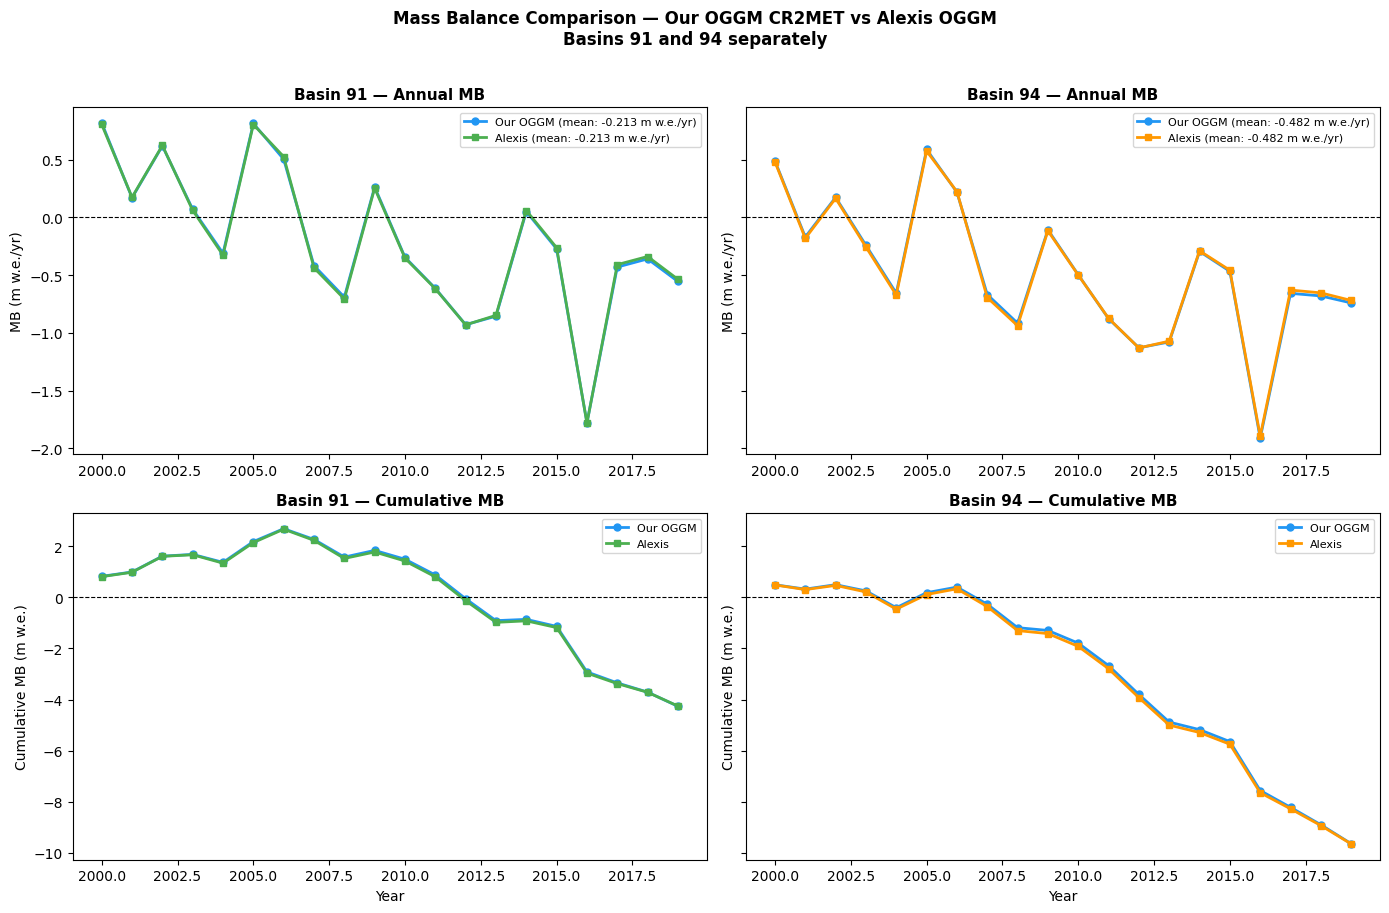

In [9]:
# Compute MB separately for 91 and 94
def basin_mb(out):
    dvol      = out['vol_series'].diff()
    area_mean = (out['area_series'] + out['area_series'].shift(1)) / 2
    mb        = dvol * ICE_DENSITY / area_mean / WATER_DENSITY
    # diff() attributes change to year N using volume at N minus N-1
    # shift by -1 so change 1999→2000 is labeled 2000, matching Alexis
    mb        = mb.shift(-1)
    return mb[(mb.index >= 2000) & (mb.index <= 2019)].dropna()

mb_91 = basin_mb(out_91)
mb_94 = basin_mb(out_94)

print(f'Our basin 91 mean MB: {mb_91.mean():.3f} m w.e./yr')
print(f'Our basin 94 mean MB: {mb_94.mean():.3f} m w.e./yr')
print(f'Alexis basin 91 mean MB: {ale_91["mb_mean"].mean():.3f} m w.e./yr')
print(f'Alexis basin 94 mean MB: {ale_94["mb_mean"].mean():.3f} m w.e./yr')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey='row')

for ax_ann, ax_cum, mb_ours, ale, basin_name, color in [
    (axes[0,0], axes[1,0], mb_91, ale_91, 'Basin 91', C_ALE91),
    (axes[0,1], axes[1,1], mb_94, ale_94, 'Basin 94', C_ALE94),
]:
    # Annual MB
    ax_ann.plot(mb_ours.index, mb_ours.values, '-o',
                color=C_OURS, linewidth=2, markersize=5,
                label=f'Our OGGM (mean: {mb_ours.mean():.3f} m w.e./yr)')
    ax_ann.plot(ale['year'], ale['mb_mean'], '-s',
                color=color, linewidth=2, markersize=5,
                label=f'Alexis (mean: {ale["mb_mean"].mean():.3f} m w.e./yr)')
    ax_ann.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax_ann.set_ylabel('MB (m w.e./yr)', fontsize=10)
    ax_ann.set_title(f'{basin_name} — Annual MB', fontsize=11, fontweight='bold')
    ax_ann.legend(fontsize=8)

    # Cumulative MB
    ax_cum.plot(mb_ours.index, mb_ours.cumsum().values, '-o',
                color=C_OURS, linewidth=2, markersize=5,
                label='Our OGGM')
    ax_cum.plot(ale['year'].values, ale['mb_mean'].cumsum().values, '-s',
                color=color, linewidth=2, markersize=5,
                label='Alexis')
    ax_cum.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax_cum.set_ylabel('Cumulative MB (m w.e.)', fontsize=10)
    ax_cum.set_xlabel('Year', fontsize=10)
    ax_cum.set_title(f'{basin_name} — Cumulative MB', fontsize=11, fontweight='bold')
    ax_cum.legend(fontsize=8)

plt.suptitle('Mass Balance Comparison — Our OGGM CR2MET vs Alexis OGGM\n'
             'Basins 91 and 94 separately',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_MB_comparison.png',
    dpi=300, bbox_inches='tight')
plt.show()

## Great, my data looks a ton like the basin data from Ale's archives!

In [10]:
"""Check which of Alexis's 44 basins have Q data"""

import os
import pandas as pd

cuencas_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/cuencasoctubre(1999)'

has_q    = []
no_q     = []

for folder in sorted(os.listdir(cuencas_path)):
    folder_path = os.path.join(cuencas_path, folder)
    if not os.path.isdir(folder_path):
        continue
    q_path = os.path.join(folder_path, 'Q_med.csv')
    bs_path = os.path.join(folder_path, 'basin_summary.csv')
    if os.path.exists(q_path) and os.path.exists(bs_path):
        q = pd.read_csv(q_path)
        bs = pd.read_csv(bs_path)
        name = q['name'].iloc[0] if 'name' in q.columns else 'unknown'
        has_q.append({'basin': int(folder), 'name': name,
                      'n_glaciers': len(pd.read_csv(
                          os.path.join(folder_path, 'volume.csv')).columns)})
    else:
        no_q.append(int(folder))

has_q_df = pd.DataFrame(has_q).sort_values('basin')
print(f'Basins WITH Q data: {len(has_q_df)}')
print(has_q_df.to_string(index=False))
print(f'\nBasins WITHOUT Q data: {sorted(no_q)}')

Basins WITH Q data: 27
 basin            name  n_glaciers
    10    Altiplanicas          33
    21         Rio Loa           3
    30 te del Pacifico         121
    34     Rio Copiapo          64
    43       Rio Elqui          24
    45      Rio Limari           5
    57       Rio Maipo         274
    60       Rio Rapel         237
    71   Rio Mataquito          25
    73       Rio Maule         180
    81       Rio Itata          64
    83     Rio Bio-Bio         125
    91    Rio Imperial          74
    94      Rio Tolten         187
   103       Rio Bueno          31
   104 ueno y R. Puelo          44
   105       Rio Puelo         182
   110 e Decima Region         574
   111 alena y R.Aisen         343
   113       Rio Aisen         382
   114  Gral. Martinez         638
   115       Rio Baker        1906
   117      Rio Pascua         626
   122 slas al oriente         504
   124 . Laguna Blanca         674
   125 mo y Magallanes         131
   128 ierra del Fuego         9

In [11]:
# Check Q_med structure for one basin — is it monthly means or full timeseries?
q_test = pd.read_csv('/Users/milliespencer/Desktop/CR2_OGGM_Paper/cuencasoctubre(1999)/57/Q_med.csv')
print(f'Columns: {q_test.columns.tolist()}')
print(f'Shape: {q_test.shape}')
print(f'Unique years: {sorted(q_test["year"].unique())}')
print(f'Unique months: {sorted(q_test["month"].unique())}')
print(q_test.head(24))

Columns: ['ID_basin', 'name', 'month', 't_max', 't_min', 'Q_mean', 'Q_sd', 'Q_mean_10_19', 'Q_sd_10_19', 'area_basin', 'lat', 'elevation', 'annual_mean', 'annual_mean_sd', 'Q_norma', 'Q_norma_sd', 'year']
Shape: (12, 17)
Unique years: [2000]
Unique months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    ID_basin       name  month  t_max  t_min   Q_mean    Q_sd  Q_mean_10_19  \
0         57  Rio Maipo      1   2019   1990  191.069  96.393       130.390   
1         57  Rio Maipo      2   2019   1990  140.286  56.930       105.856   
2         57  Rio Maipo      3   2019   1990   98.320  32.536        77.533   
3         57  Rio Maipo      4   2019   1990   74.053  20.556        65.910   
4         57  Rio Maipo      5   2019   1990   63.274  18.046        51.487   
5         57  Rio Maipo      6   2019   1990   65.729  18.313        48.909   
6         57  Rio Maipo      7   2019   1990   64.520  20.650        44.203   
7         57  Rio Maipo      8   2018   1990   67.517  20.751        46

## hmm so Ale's dataset just has mean monthly Q over the full time period, which means it cant tell us how relative contribution of glacier melt has changed over time. But, it can at least let us see how relative contributions on avg. vary spatially. Plus will take a long time to download all Q data for chile.  

In [14]:
"""
Cell D: Climatological glacier ablation / Q for all 27 basins with Q data
Uses Q_mean from Alexis's Q_med.csv (long-term monthly climatology)
and mean annual/monthly ablation from OGGM CR2MET (2000-2019)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cuencas_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/cuencasoctubre(1999)'

basins_with_q = [10, 21, 30, 34, 43, 45, 57, 60, 71, 73, 81, 83, 91, 94,
                 103, 104, 105, 110, 111, 113, 114, 115, 117, 122, 124, 125, 128]

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Loop over basins ───────────────────────────────────────────────────────
results = []

for basin_code in basins_with_q:

    # ── Load Q_med ─────────────────────────────────────────────────────────
    q_path = os.path.join(cuencas_path, str(basin_code), 'Q_med.csv')
    q_med  = pd.read_csv(q_path)
    name   = q_med['name'].iloc[0]
    area_basin_km2 = q_med['area_basin'].iloc[0]

    # Monthly mean Q (m³/s) → m³/month
    q_med         = q_med.sort_values('month')
    days_in_month = [31,28,31,30,31,30,31,31,30,31,30,31]
    q_m3_month    = q_med['Q_mean'].values * np.array(days_in_month) * 86400
    q_annual      = q_m3_month.sum()

    # ── Extract glacier outputs from OGGM ──────────────────────────────────
    out = extract_basin_outputs(basin_code, rgi, nc_datasets)
    if out is None:
        print(f'Basin {basin_code} ({name}): no glacier data — skipping')
        continue

    # Mean monthly ablation over 2000-2019 (m³ water)
    melt            = out['melt_monthly']
    melt_2000_2019  = melt.loc['2000':'2019']
    melt_mean_monthly = melt_2000_2019.groupby(
        melt_2000_2019.index.month).mean().values  # (12,)
    melt_mean_annual  = melt_mean_monthly.sum()

    # Fractions
    frac_ablation_monthly = (melt_mean_monthly / q_m3_month * 100).clip(0, 100)
    frac_ablation_annual  = melt_mean_annual / q_annual * 100

    lat = q_med['lat'].iloc[0]

    results.append({
        'basin':                basin_code,
        'name':                 name,
        'lat':                  lat,
        'n_glaciers':           out['n_glaciers'],
        'glacier_area_km2':     out['glacier_area_km2'],
        'basin_area_km2':       area_basin_km2,
        'glacier_pct':          out['glacier_area_km2'] / area_basin_km2 * 100,
        'Q_annual_m3':          q_annual,
        'ablation_annual_m3':   melt_mean_annual,
        'frac_ablation_pct':    frac_ablation_annual,
        'frac_ablation_monthly': frac_ablation_monthly,
        'q_m3_month':           q_m3_month,
        'melt_mean_monthly':    melt_mean_monthly,
    })

    print(f'Basin {basin_code:3d} {name:25s} | '
          f'ablation/Q: {frac_ablation_annual:5.1f}% | '
          f'lat: {lat:.1f}°')

results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ['frac_ablation_monthly',
                                          'q_m3_month',
                                          'melt_mean_monthly']}
                            for r in results])
results_df = results_df.sort_values('lat', ascending=False)

print(f'\n✓ {len(results)} basins processed')
print(f'\nSummary:')
print(results_df[['basin','name','lat','glacier_area_km2',
                   'frac_ablation_pct']].to_string(index=False))


Basin 10: 34 glaciers across clusters ['OT3']
  OT3: matched 34 glaciers
Basin  10 Altiplanicas              | ablation/Q:   6.9% | lat: -18.0°

Basin 21: 3 glaciers across clusters ['DA1']
  DA1: matched 3 glaciers
Basin  21 Rio Loa                   | ablation/Q:   3.6% | lat: -21.7°

Basin 30: 121 glaciers across clusters ['DA1']
  DA1: matched 121 glaciers
Basin  30 te del Pacifico           | ablation/Q:  65.4% | lat: -26.5°

Basin 34: 64 glaciers across clusters ['DA1']
  DA1: matched 64 glaciers
Basin  34 Rio Copiapo               | ablation/Q: 300.3% | lat: -27.3°

Basin 43: 24 glaciers across clusters ['DA2', 'DA1']
  DA2: matched 2 glaciers
  DA1: matched 22 glaciers
Basin  43 Rio Elqui                 | ablation/Q:   2.3% | lat: -29.9°

Basin 45: 5 glaciers across clusters ['DA1']
  DA1: matched 5 glaciers
Basin  45 Rio Limari                | ablation/Q:   0.2% | lat: -30.7°

Basin 57: 274 glaciers across clusters ['DA3', 'DA2']
  DA3: matched 143 glaciers
  DA2: matched 1

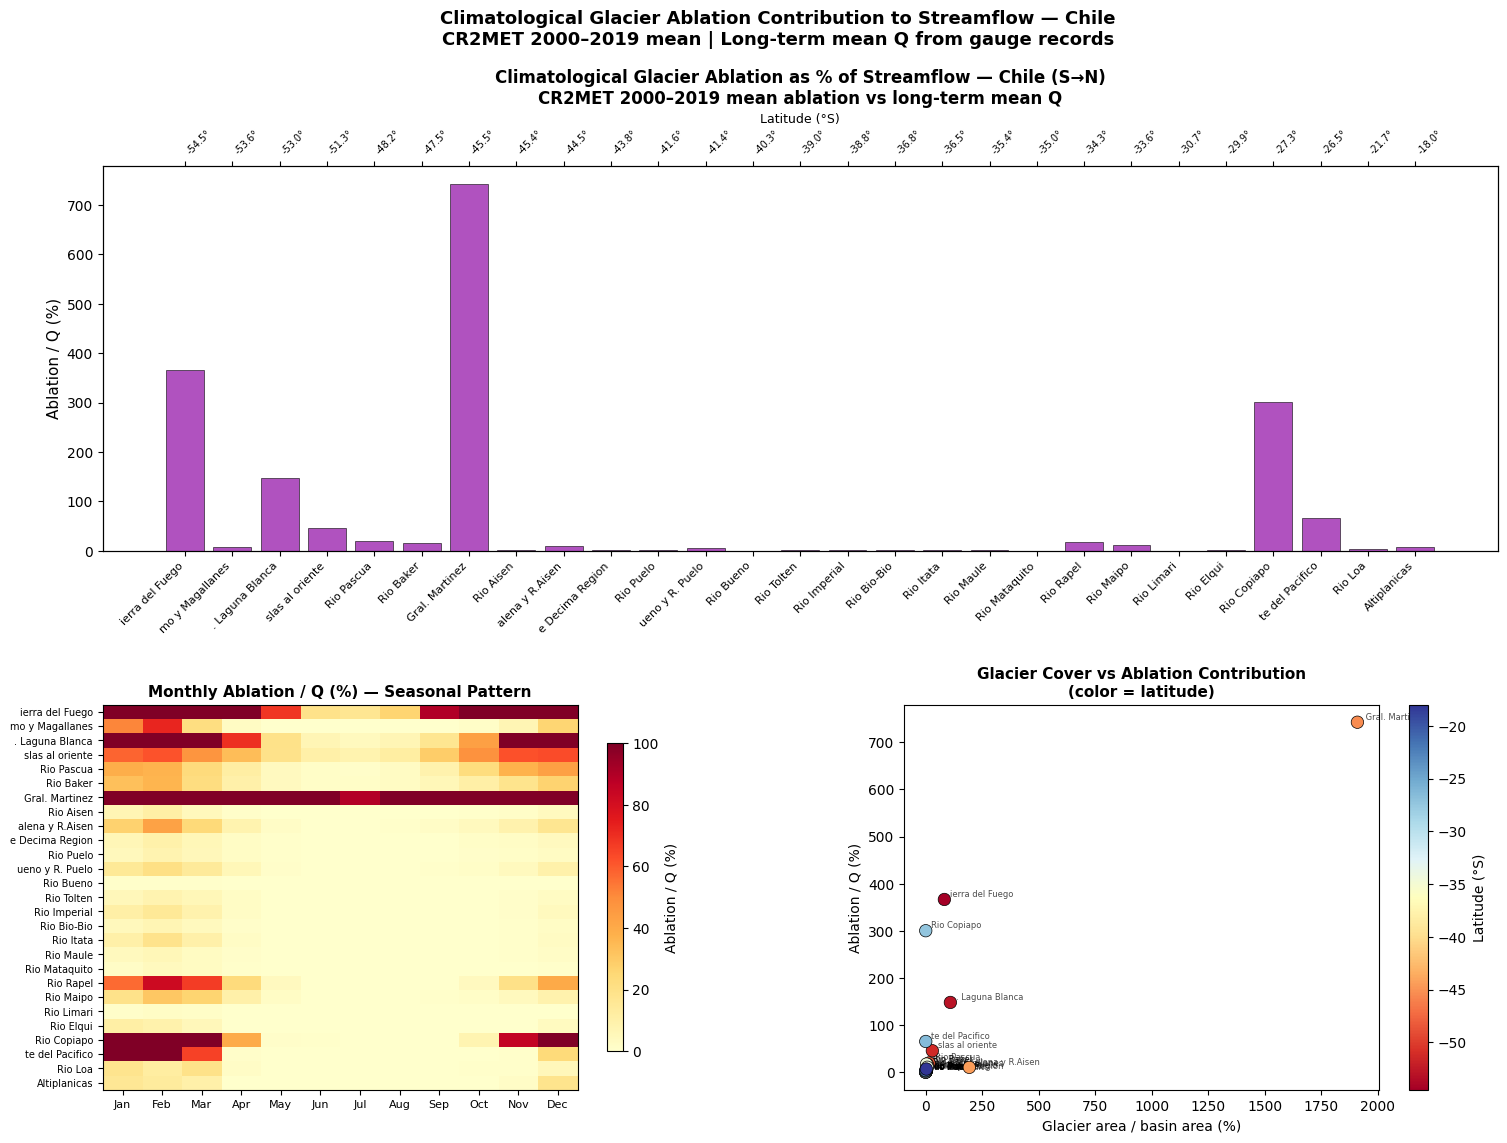

In [15]:
"""
Cell E: Plot climatological glacier ablation / Q across Chile
"""

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Sort S to N for plotting
res_plot = sorted(results, key=lambda x: x['lat'])
lats     = [r['lat']               for r in res_plot]
frac_abl = [r['frac_ablation_pct'] for r in res_plot]
gl_pct   = [r['glacier_pct']       for r in res_plot]

C_ABL = '#9C27B0'

# ── Panel 1: Annual ablation/Q N→S bar chart ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(len(res_plot))
ax1.bar(x, frac_abl, color=C_ABL, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([r['name'] for r in res_plot],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Ablation / Q (%)', fontsize=11)
ax1.set_title('Climatological Glacier Ablation as % of Streamflow — Chile (S→N)\n'
              'CR2MET 2000–2019 mean ablation vs long-term mean Q',
              fontsize=12, fontweight='bold')

# Latitude on top axis
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
ax1b.set_xticks(x)
ax1b.set_xticklabels([f'{l:.1f}°' for l in lats],
                     rotation=45, ha='left', fontsize=7)
ax1b.set_xlabel('Latitude (°S)', fontsize=9)

# ── Panel 2: Seasonal heatmap ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
heatmap_data = np.array([r['frac_ablation_monthly'] for r in res_plot])
vmax = min(100, np.percentile(heatmap_data, 95))
im   = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
                  vmin=0, vmax=vmax)
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_NAMES, fontsize=8)
ax2.set_yticks(range(len(res_plot)))
ax2.set_yticklabels([r['name'] for r in res_plot], fontsize=7)
ax2.set_title('Monthly Ablation / Q (%) — Seasonal Pattern',
              fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Ablation / Q (%)', shrink=0.8)

# ── Panel 3: Glacier area % vs ablation/Q scatter ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
sc  = ax3.scatter(gl_pct, frac_abl,
                  c=lats, cmap='RdYlBu', s=80,
                  edgecolors='black', linewidths=0.5, zorder=5)
for r in res_plot:
    ax3.annotate(r['name'],
                 (r['glacier_pct'], r['frac_ablation_pct']),
                 fontsize=6, alpha=0.7,
                 xytext=(4, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax3, label='Latitude (°S)')
ax3.set_xlabel('Glacier area / basin area (%)', fontsize=10)
ax3.set_ylabel('Ablation / Q (%)', fontsize=10)
ax3.set_title('Glacier Cover vs Ablation Contribution\n(color = latitude)',
              fontsize=11, fontweight='bold')

plt.suptitle('Climatological Glacier Ablation Contribution to Streamflow — Chile\n'
             'CR2MET 2000–2019 mean | Long-term mean Q from gauge records',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Chile_glacier_contribution_climatological.png',
    dpi=300, bbox_inches='tight')
plt.show()

## confused as to how glacier melt could represent more than 100% of streamflow? maybe basin mismatch? Ask Ale. 

In [16]:
# Check the worst offenders
for r in results:
    if r['frac_ablation_pct'] > 50:
        print(f"\nBasin {r['basin']} — {r['name']}")
        print(f"  Glacier area:      {r['glacier_area_km2']:.1f} km²")
        print(f"  Basin area:        {r['basin_area_km2']:.1f} km²")
        print(f"  Glacier/basin:     {r['glacier_pct']:.1f}%")
        print(f"  Mean annual Q:     {r['Q_annual_m3']:.2e} m³/yr")
        print(f"  Mean ablation:     {r['ablation_annual_m3']:.2e} m³/yr")
        print(f"  Ablation/Q:        {r['frac_ablation_pct']:.1f}%")
        print(f"  Monthly Q (m³/month):     {r['q_m3_month']}")
        print(f"  Monthly melt (m³/month):  {r['melt_mean_monthly']}")


Basin 30 — te del Pacifico
  Glacier area:      33.7 km²
  Basin area:        12311.0 km²
  Glacier/basin:     0.3%
  Mean annual Q:     1.96e+07 m³/yr
  Mean ablation:     1.28e+07 m³/yr
  Ablation/Q:        65.4%
  Monthly Q (m³/month):     [1553472.  1473292.8 1703462.4 1669248.  1754352.  1583712.  1609718.4
 1639180.8 1695168.  1781136.  1594080.  1580256. ]
  Monthly melt (m³/month):  [ 7.1233360e+06  4.2035450e+06  1.1143216e+06  1.4764865e+04
 -6.9382440e+02 -7.7205945e+02 -7.7205945e+02 -7.7205945e+02
 -7.7205945e+02 -3.4046918e+02  1.1251904e+04  3.7134100e+05]

Basin 34 — Rio Copiapo
  Glacier area:      37.8 km²
  Basin area:        18549.9 km²
  Glacier/basin:     0.2%
  Mean annual Q:     7.11e+06 m³/yr
  Mean ablation:     2.13e+07 m³/yr
  Ablation/Q:        300.3%
  Monthly Q (m³/month):     [674956.8 716083.2 664243.2 567648.  744595.2 889056.  889228.8 653529.6
 456192.  350870.4 279936.  222307.2]
  Monthly melt (m³/month):  [ 9.4195480e+06  6.1172910e+06  3.0062740

In [17]:
# Check which clusters these problem basins draw from
problem_basins = [30, 34, 114, 124, 128]
for basin_code in problem_basins:
    basin_rgi = rgi[rgi['COD_CUEN'] == basin_code]
    print(f'\nBasin {basin_code}:')
    print(f'  Clusters: {basin_rgi["Cluster"].unique().tolist()}')
    print(f'  N glaciers: {len(basin_rgi)}')
    print(f'  Glacier area (RGI): {basin_rgi["Area"].sum():.1f} km²')
    
    # Check raw melt values from NetCDF for these glaciers
    for cluster in basin_rgi['Cluster'].unique():
        if cluster not in nc_datasets:
            print(f'  {cluster}: NOT LOADED')
            continue
        ds = nc_datasets[cluster]
        rgi_ids_basin = basin_rgi[basin_rgi['Cluster'] == cluster]['RGIId'].values
        mask = np.isin(ds['rgi_id'].values, rgi_ids_basin)
        print(f'  {cluster}: {mask.sum()} matched, '
              f'{len(rgi_ids_basin)} expected')


Basin 30:
  Clusters: ['DA1']
  N glaciers: 121
  Glacier area (RGI): 33.1 km²
  DA1: 121 matched, 121 expected

Basin 34:
  Clusters: ['DA1']
  N glaciers: 64
  Glacier area (RGI): 37.9 km²
  DA1: 64 matched, 64 expected

Basin 114:
  Clusters: ['WA6', 'WA3', 'WA4', 'WA2']
  N glaciers: 640
  Glacier area (RGI): 3512.5 km²
  WA6: 444 matched, 444 expected
  WA3: 151 matched, 151 expected
  WA4: 8 matched, 8 expected
  WA2: 37 matched, 37 expected

Basin 124:
  Clusters: ['WA6', 'WA4']
  N glaciers: 693
  Glacier area (RGI): 695.5 km²
  WA6: 670 matched, 670 expected
  WA4: 23 matched, 23 expected

Basin 128:
  Clusters: ['WA4', 'WA6']
  N glaciers: 1014
  Glacier area (RGI): 2941.9 km²
  WA4: 619 matched, 619 expected
  WA6: 395 matched, 395 expected


## exclude any basin where: Glacier area > basin area (physically impossible — glacier can't be larger than catchment)


In [18]:
"""
Cell D2: Flag and exclude basins where glacier area > basin area
"""

results_clean    = []
results_excluded = []

for r in results:
    if r['glacier_area_km2'] > r['basin_area_km2']:
        results_excluded.append(r)
        print(f'EXCLUDED basin {r["basin"]:3d} {r["name"]:25s}: '
              f'glacier area ({r["glacier_area_km2"]:.0f} km²) '
              f'> basin area ({r["basin_area_km2"]:.0f} km²)')
    else:
        results_clean.append(r)

print(f'\n✓ Clean basins:    {len(results_clean)}')
print(f'✗ Excluded basins: {len(results_excluded)}')
print(f'\nClean basin summary:')
for r in sorted(results_clean, key=lambda x: x['lat'], reverse=True):
    print(f'  {r["basin"]:3d} {r["name"]:25s} | '
          f'ablation/Q: {r["frac_ablation_pct"]:5.1f}% | '
          f'lat: {r["lat"]:.1f}°')

EXCLUDED basin 111 alena y R.Aisen          : glacier area (316 km²) > basin area (164 km²)
EXCLUDED basin 114  Gral. Martinez          : glacier area (3289 km²) > basin area (172 km²)
EXCLUDED basin 124 . Laguna Blanca          : glacier area (660 km²) > basin area (604 km²)

✓ Clean basins:    24
✗ Excluded basins: 3

Clean basin summary:
   10 Altiplanicas              | ablation/Q:   6.9% | lat: -18.0°
   21 Rio Loa                   | ablation/Q:   3.6% | lat: -21.7°
   30 te del Pacifico           | ablation/Q:  65.4% | lat: -26.5°
   34 Rio Copiapo               | ablation/Q: 300.3% | lat: -27.3°
   43 Rio Elqui                 | ablation/Q:   2.3% | lat: -29.9°
   45 Rio Limari                | ablation/Q:   0.2% | lat: -30.7°
   57 Rio Maipo                 | ablation/Q:  10.6% | lat: -33.6°
   60 Rio Rapel                 | ablation/Q:  17.5% | lat: -34.3°
   71 Rio Mataquito             | ablation/Q:   0.3% | lat: -35.0°
   73 Rio Maule                 | ablation/Q:   0.6% |

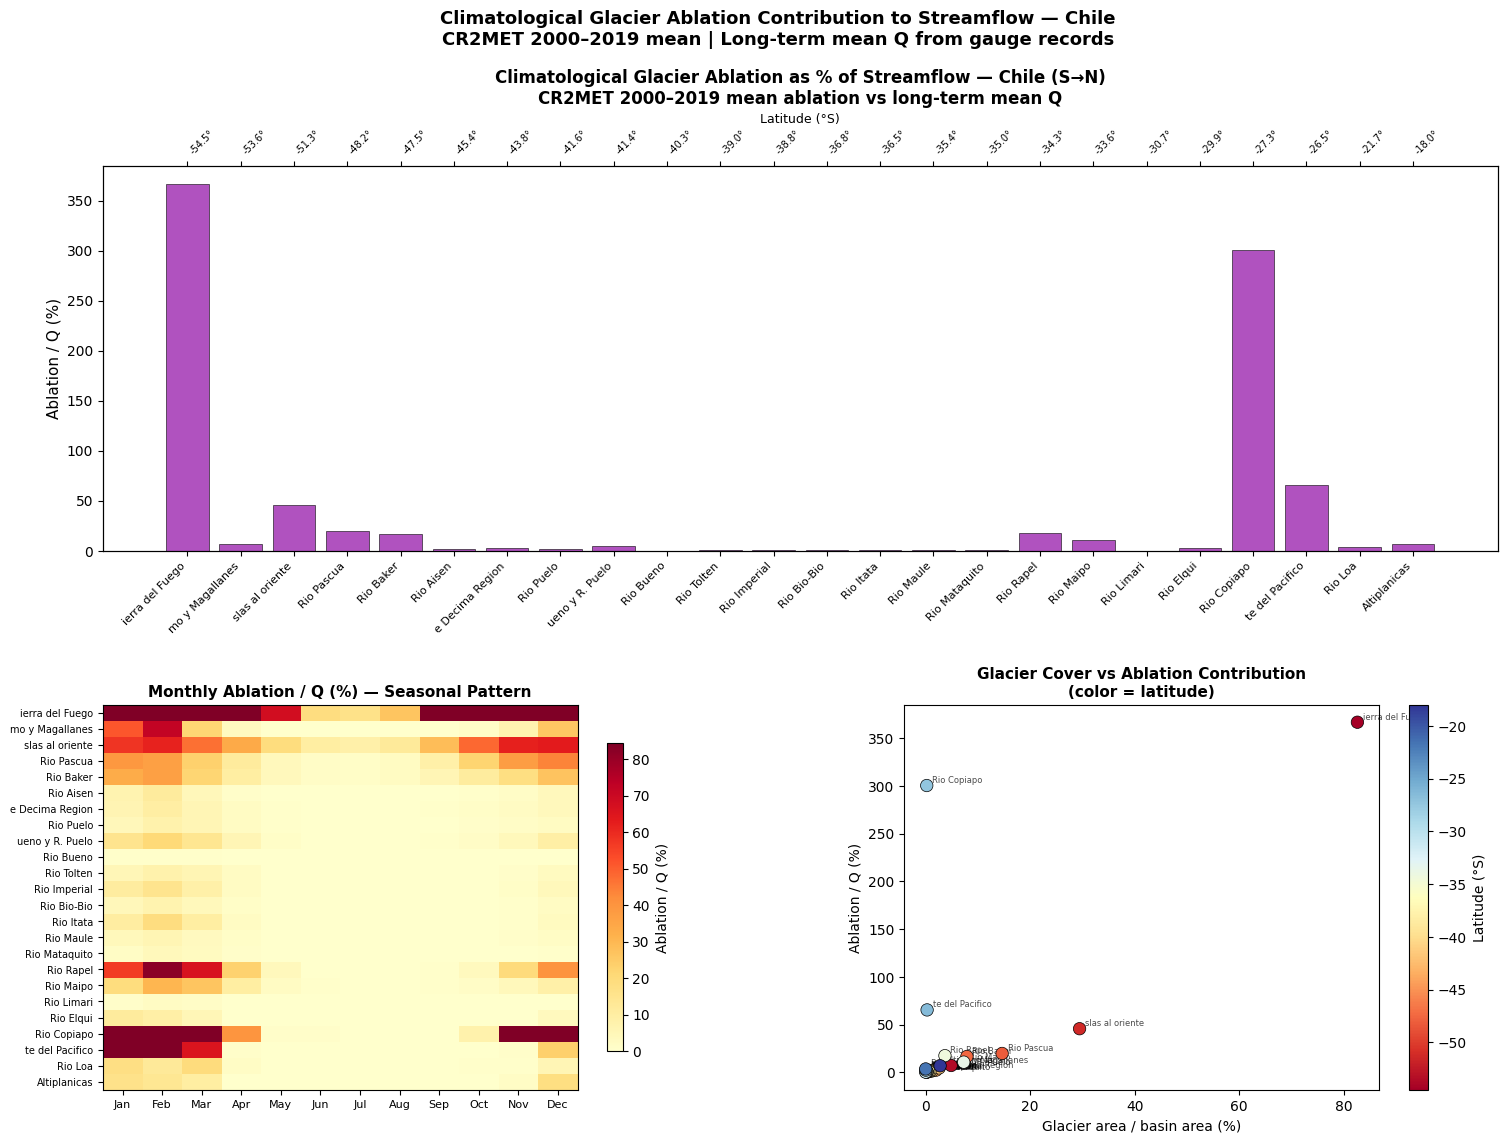

In [21]:
"""
Cell E: Plot climatological glacier ablation / Q across Chile (clean basins only)
"""

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Sort S to N for plotting
res_plot = sorted(results_clean, key=lambda x: x['lat'])
lats     = [r['lat']               for r in res_plot]
frac_abl = [r['frac_ablation_pct'] for r in res_plot]
gl_pct   = [r['glacier_pct']       for r in res_plot]

C_ABL = '#9C27B0'

# ── Panel 1: Annual ablation/Q S→N bar chart ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(len(res_plot))
ax1.bar(x, frac_abl, color=C_ABL, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([r['name'] for r in res_plot],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Ablation / Q (%)', fontsize=11)
ax1.set_title('Climatological Glacier Ablation as % of Streamflow — Chile (S→N)\n'
              'CR2MET 2000–2019 mean ablation vs long-term mean Q',
              fontsize=12, fontweight='bold')

# Latitude on top axis
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
ax1b.set_xticks(x)
ax1b.set_xticklabels([f'{l:.1f}°' for l in lats],
                     rotation=45, ha='left', fontsize=7)
ax1b.set_xlabel('Latitude (°S)', fontsize=9)

# ── Panel 2: Seasonal heatmap ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
heatmap_data = np.array([r['frac_ablation_monthly'] for r in res_plot])
vmax = min(100, np.percentile(heatmap_data, 95))
im   = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
                  vmin=0, vmax=vmax)
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_NAMES, fontsize=8)
ax2.set_yticks(range(len(res_plot)))
ax2.set_yticklabels([r['name'] for r in res_plot], fontsize=7)
ax2.set_title('Monthly Ablation / Q (%) — Seasonal Pattern',
              fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Ablation / Q (%)', shrink=0.8)

# ── Panel 3: Glacier area % vs ablation/Q scatter ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
sc  = ax3.scatter(gl_pct, frac_abl,
                  c=lats, cmap='RdYlBu', s=80,
                  edgecolors='black', linewidths=0.5, zorder=5)
for r in res_plot:
    ax3.annotate(r['name'],
                 (r['glacier_pct'], r['frac_ablation_pct']),
                 fontsize=6, alpha=0.7,
                 xytext=(4, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax3, label='Latitude (°S)')
ax3.set_xlabel('Glacier area / basin area (%)', fontsize=10)
ax3.set_ylabel('Ablation / Q (%)', fontsize=10)
ax3.set_title('Glacier Cover vs Ablation Contribution\n(color = latitude)',
              fontsize=11, fontweight='bold')

plt.suptitle('Climatological Glacier Ablation Contribution to Streamflow — Chile\n'
             'CR2MET 2000–2019 mean | Long-term mean Q from gauge records',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Chile_glacier_contribution_climatological.png',
    dpi=300, bbox_inches='tight')
plt.show()

## still a few over 100%. now removing those and just plotting basins where ablation is less than streamflow: (but still should look into why this is the case...)

In [22]:
"""
Cell D3: Flag and exclude basins where glacier area > basin area
         OR ablation > Q (physically impossible)
"""

results_clean    = []
results_excluded = []

for r in results:
    reasons = []
    if r['glacier_area_km2'] > r['basin_area_km2']:
        reasons.append(f'glacier area ({r["glacier_area_km2"]:.0f} km²) '
                       f'> basin area ({r["basin_area_km2"]:.0f} km²)')
    if r['frac_ablation_pct'] > 100:
        reasons.append(f'ablation > Q ({r["frac_ablation_pct"]:.0f}%)')

    if reasons:
        results_excluded.append(r)
        print(f'EXCLUDED basin {r["basin"]:3d} {r["name"]:25s}: '
              f'{", ".join(reasons)}')
    else:
        results_clean.append(r)

print(f'\n✓ Clean basins:    {len(results_clean)}')
print(f'✗ Excluded basins: {len(results_excluded)}')
print(f'\nClean basin summary:')
for r in sorted(results_clean, key=lambda x: x['lat'], reverse=True):
    print(f'  {r["basin"]:3d} {r["name"]:25s} | '
          f'ablation/Q: {r["frac_ablation_pct"]:5.1f}% | '
          f'lat: {r["lat"]:.1f}°')

EXCLUDED basin  34 Rio Copiapo              : ablation > Q (300%)
EXCLUDED basin 111 alena y R.Aisen          : glacier area (316 km²) > basin area (164 km²)
EXCLUDED basin 114  Gral. Martinez          : glacier area (3289 km²) > basin area (172 km²), ablation > Q (743%)
EXCLUDED basin 124 . Laguna Blanca          : glacier area (660 km²) > basin area (604 km²), ablation > Q (148%)
EXCLUDED basin 128 ierra del Fuego          : ablation > Q (367%)

✓ Clean basins:    22
✗ Excluded basins: 5

Clean basin summary:
   10 Altiplanicas              | ablation/Q:   6.9% | lat: -18.0°
   21 Rio Loa                   | ablation/Q:   3.6% | lat: -21.7°
   30 te del Pacifico           | ablation/Q:  65.4% | lat: -26.5°
   43 Rio Elqui                 | ablation/Q:   2.3% | lat: -29.9°
   45 Rio Limari                | ablation/Q:   0.2% | lat: -30.7°
   57 Rio Maipo                 | ablation/Q:  10.6% | lat: -33.6°
   60 Rio Rapel                 | ablation/Q:  17.5% | lat: -34.3°
   71 Rio Mata

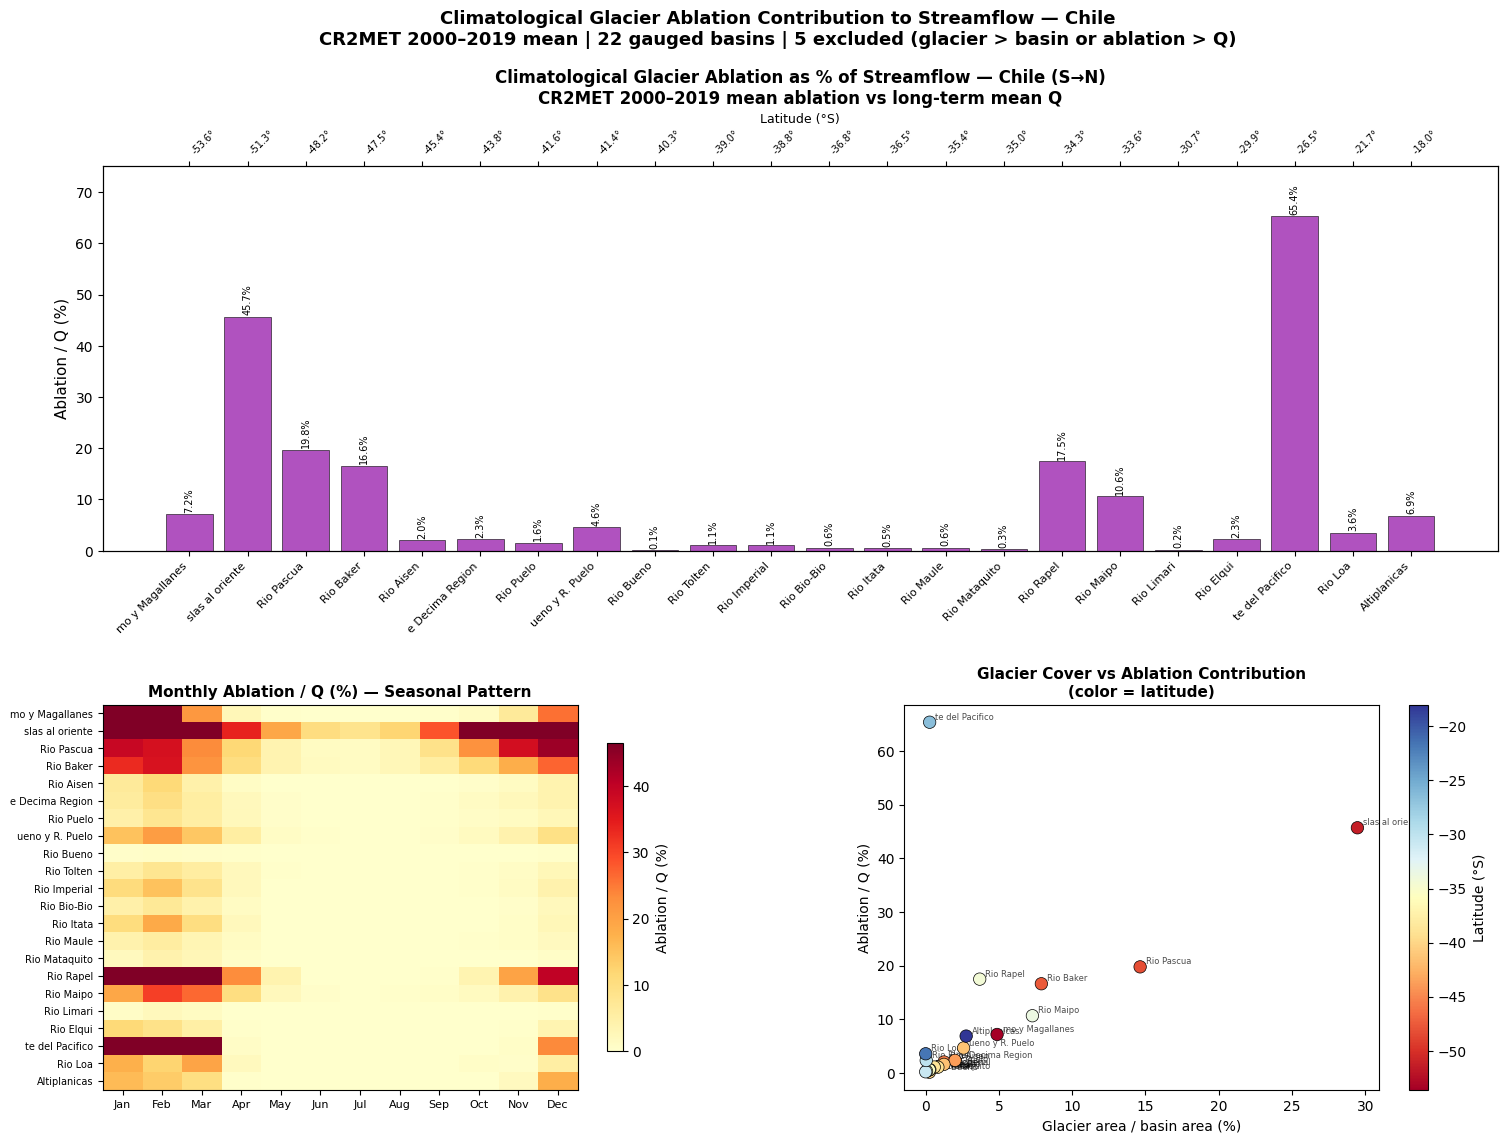

In [24]:
"""
Cell E3: Plot climatological glacier ablation / Q across Chile (clean basins only)
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Sort S to N for plotting
res_plot = sorted(results_clean, key=lambda x: x['lat'])
lats     = [r['lat']               for r in res_plot]
frac_abl = [r['frac_ablation_pct'] for r in res_plot]
gl_pct   = [r['glacier_pct']       for r in res_plot]

C_ABL = '#9C27B0'

# ── Panel 1: Annual ablation/Q S→N bar chart ───────────────────────────────
ax1  = fig.add_subplot(gs[0, :])
x    = np.arange(len(res_plot))
bars = ax1.bar(x, frac_abl, color=C_ABL, alpha=0.8,
               edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([r['name'] for r in res_plot],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Ablation / Q (%)', fontsize=11)
ax1.set_ylim(0, max(frac_abl) * 1.15)
ax1.set_title('Climatological Glacier Ablation as % of Streamflow — Chile (S→N)\n'
              'CR2MET 2000–2019 mean ablation vs long-term mean Q',
              fontsize=12, fontweight='bold')

# Value labels on bars
for bar, val in zip(bars, frac_abl):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=7, rotation=90)

# Latitude on top axis
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
ax1b.set_xticks(x)
ax1b.set_xticklabels([f'{l:.1f}°' for l in lats],
                     rotation=45, ha='left', fontsize=7)
ax1b.set_xlabel('Latitude (°S)', fontsize=9)

# ── Panel 2: Seasonal heatmap ──────────────────────────────────────────────
ax2          = fig.add_subplot(gs[1, 0])
heatmap_data = np.array([r['frac_ablation_monthly'] for r in res_plot])
heatmap_data = heatmap_data.clip(0, 100)
vmax         = min(100, np.percentile(heatmap_data, 95))
im           = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
                          vmin=0, vmax=vmax)
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_NAMES, fontsize=8)
ax2.set_yticks(range(len(res_plot)))
ax2.set_yticklabels([r['name'] for r in res_plot], fontsize=7)
ax2.set_title('Monthly Ablation / Q (%) — Seasonal Pattern',
              fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Ablation / Q (%)', shrink=0.8)

# ── Panel 3: Glacier area % vs ablation/Q scatter ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
sc  = ax3.scatter(gl_pct, frac_abl,
                  c=lats, cmap='RdYlBu', s=80,
                  edgecolors='black', linewidths=0.5, zorder=5)
for r in res_plot:
    ax3.annotate(r['name'],
                 (r['glacier_pct'], r['frac_ablation_pct']),
                 fontsize=6, alpha=0.7,
                 xytext=(4, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax3, label='Latitude (°S)')
ax3.set_xlabel('Glacier area / basin area (%)', fontsize=10)
ax3.set_ylabel('Ablation / Q (%)', fontsize=10)
ax3.set_title('Glacier Cover vs Ablation Contribution\n(color = latitude)',
              fontsize=11, fontweight='bold')

plt.suptitle('Climatological Glacier Ablation Contribution to Streamflow — Chile\n'
             f'CR2MET 2000–2019 mean | {len(results_clean)} gauged basins | '
             f'{len(results_excluded)} excluded (glacier > basin or ablation > Q)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Chile_glacier_contribution_climatological.png',
    dpi=300, bbox_inches='tight')
plt.show()

In [25]:
print('Basins ranked by glacier ablation contribution to streamflow:')
print(f'{"Rank":<5} {"Basin":<6} {"Name":<25} {"Lat":>6} {"Ablation/Q":>12}')
print('-' * 58)
for i, r in enumerate(sorted(results_clean, 
                               key=lambda x: x['frac_ablation_pct'], 
                               reverse=True), 1):
    print(f'{i:<5} {r["basin"]:<6} {r["name"]:<25} {r["lat"]:>6.1f}°  '
          f'{r["frac_ablation_pct"]:>10.1f}%')

Basins ranked by glacier ablation contribution to streamflow:
Rank  Basin  Name                         Lat   Ablation/Q
----------------------------------------------------------
1     30     te del Pacifico            -26.5°        65.4%
2     122    slas al oriente            -51.3°        45.7%
3     117    Rio Pascua                 -48.2°        19.8%
4     60     Rio Rapel                  -34.3°        17.5%
5     115    Rio Baker                  -47.5°        16.6%
6     57     Rio Maipo                  -33.6°        10.6%
7     125    mo y Magallanes            -53.6°         7.2%
8     10     Altiplanicas               -18.0°         6.9%
9     104    ueno y R. Puelo            -41.4°         4.6%
10    21     Rio Loa                    -21.7°         3.6%
11    110    e Decima Region            -43.8°         2.3%
12    43     Rio Elqui                  -29.9°         2.3%
13    113    Rio Aisen                  -45.4°         2.0%
14    105    Rio Puelo                  

In [28]:
print('Basins ranked by February glacier ablation contribution to streamflow:')
print(f'{"Rank":<5} {"Basin":<6} {"Name":<25} {"Lat":>6} {"February":>10} {"Annual":>10}')
print('-' * 68)

for i, r in enumerate(sorted(results_clean,
                               key=lambda x: x['frac_ablation_monthly'][1],
                               reverse=True), 1):
    feb_frac = min(r['frac_ablation_monthly'][1], 100)
    print(f'{i:<5} {r["basin"]:<6} {r["name"]:<25} {r["lat"]:>6.1f}°  '
          f'{feb_frac:>9.1f}%  {r["frac_ablation_pct"]:>9.1f}%')

Basins ranked by February glacier ablation contribution to streamflow:
Rank  Basin  Name                         Lat   February     Annual
--------------------------------------------------------------------
1     30     te del Pacifico            -26.5°      100.0%       65.4%
2     60     Rio Rapel                  -34.3°       82.2%       17.5%
3     125    mo y Magallanes            -53.6°       71.9%        7.2%
4     122    slas al oriente            -51.3°       61.6%       45.7%
5     117    Rio Pascua                 -48.2°       36.8%       19.8%
6     115    Rio Baker                  -47.5°       36.6%       16.6%
7     57     Rio Maipo                  -33.6°       30.6%       10.6%
8     104    ueno y R. Puelo            -41.4°       20.6%        4.6%
9     81     Rio Itata                  -36.5°       18.5%        0.5%
10    91     Rio Imperial               -38.8°       15.0%        1.1%
11    10     Altiplanicas               -18.0°       13.6%        6.9%
12    21   

## again, i want to re-run this with montly streamflow data for all basins so that I can look at how relative glacier melt contributions have changed over time, not just the % of avg. streamflow over the study period. But really interesting results for now! Surprised to see what a large contribution some of the glaciers in Araucanía make to streamflow during peak ablation. I imagine this increased as summertime became more rain free in Araucanía. Curious whether glaciers are still contributing relatively more to summer streamflow, despite (likley) having passed peak water, due to declining summer precip. 

Year  Melt (m³)    Area (km²)   MB (m w.e.)   Melt/Q (%)
-----------------------------------------------------------------
2000  1.99e+08   97.58      -0.513         9.1%
2001  2.71e+08   104.64      0.596         10.4%
2002  2.34e+08   102.12      -0.058         9.3%
2003  2.36e+08   101.96      0.319         10.2%
2004  2.76e+08   100.36      -0.140         11.9%
2005  2.36e+08   98.94      -0.543         9.2%
2006  2.58e+08   107.60      0.662         19.3%
2007  2.50e+08   104.52      0.311         14.2%
2008  3.30e+08   103.71      -0.587         14.5%
2009  2.67e+08   100.07      -0.842         10.3%
2010  2.38e+08   100.10      0.014         12.3%
2011  2.79e+08   99.24      -0.448         14.1%
2012  2.74e+08   98.68      -0.791         14.2%
2013  2.87e+08   97.53      -1.063         16.2%
2014  2.31e+08   96.83      -1.005         11.5%
2015  2.94e+08   96.83      -0.181         19.0%
2016  3.13e+08   96.98      -0.403         34.1%
2017  2.68e+08   95.56      -1.868         

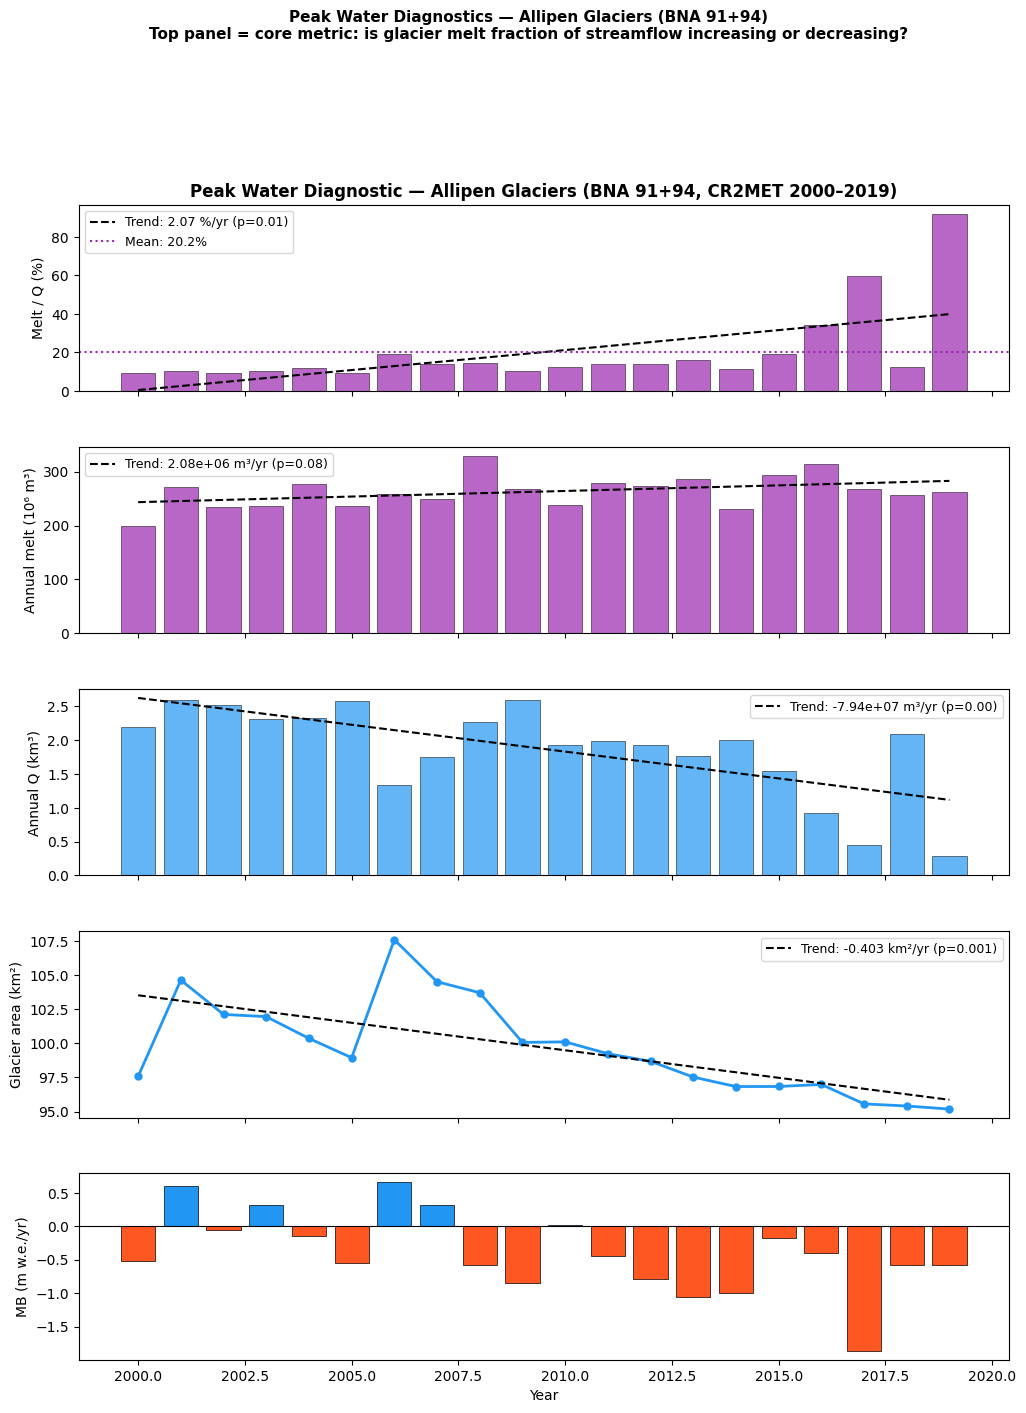

In [40]:
"""Cell 8: Peak water diagnostic for Allipen (BNA 91 + 94)
   Combines melt/Q ratio (core peak water metric) with area and MB context
"""

from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C_Q     = '#2196F3'
C_MELT  = '#9C27B0'
C_IMBAL = '#FF5722'

# ── Reload CAMELS Q ───────────────────────────────────────────────────────
q_raw = pd.read_csv('/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001/q_m3s_mon.csv')
q_raw['date']  = pd.to_datetime(q_raw['date'])
q_raw          = q_raw.set_index('date')
q_m3_month     = (q_raw['9402001'] * q_raw['9402001'].index.days_in_month * 86400).dropna()
q_ann_allipen  = q_m3_month.resample('YE').sum()
q_ann_allipen.index = q_ann_allipen.index.year
q_ann_allipen  = q_ann_allipen.loc[2000:2019]

# ── Annual melt volume ────────────────────────────────────────────────────
melt_allipen   = out_91['melt_monthly'] + out_94['melt_monthly']
melt_ann       = melt_allipen.resample('YE').sum()
melt_ann.index = melt_ann.index.year
melt_ann       = melt_ann.loc[2000:2019]

# ── Annual glacier area ───────────────────────────────────────────────────
area_allipen = (out_91['area_series'] + out_94['area_series']) / 1e6  # km²
area_ann     = area_allipen.loc[2000:2019]

# ── Annual MB ─────────────────────────────────────────────────────────────
mb_ann = mb_allipen.loc[2000:2019]

# ── Melt / Q fraction ─────────────────────────────────────────────────────
common = melt_ann.index.intersection(q_ann_allipen.index)
melt_c = melt_ann.loc[common]
q_c    = q_ann_allipen.loc[common]
frac_c = (melt_c / q_c * 100).clip(0, 100)

# ── Trends ────────────────────────────────────────────────────────────────
years_arr = np.array(common, dtype=float)

slope_melt, int_melt, _, p_melt, _ = linregress(years_arr, melt_c.values)
slope_q,    int_q,    _, p_q,    _ = linregress(years_arr, q_c.values)
slope_frac, int_frac, _, p_frac, _ = linregress(years_arr, frac_c.values)
slope_a,    int_a,    _, p_a,    _ = linregress(years_arr, area_ann.values)

print('Year  Melt (m³)    Area (km²)   MB (m w.e.)   Melt/Q (%)')
print('-' * 65)
for yr in common:
    mb_val   = mb_ann[yr]   if yr in mb_ann.index   else float('nan')
    frac_val = frac_c[yr]   if yr in frac_c.index   else float('nan')
    print(f'{yr}  {melt_ann[yr]:.2e}   {area_ann[yr]:.2f}      '
          f'{mb_val:.3f}         {frac_val:.1f}%')

print(f'\nMelt volume trend:     {slope_melt:.2e} m³/yr  (p={p_melt:.3f}) '
      f'→ {"INCREASING" if slope_melt > 0 else "DECREASING"} '
      f'{"(significant)" if p_melt < 0.05 else "(not significant)"}')
print(f'Annual Q trend:        {slope_q:.2e} m³/yr  (p={p_q:.3f}) '
      f'→ {"INCREASING" if slope_q > 0 else "DECREASING"} '
      f'{"(significant)" if p_q < 0.05 else "(not significant)"}')
print(f'Melt/Q fraction trend: {slope_frac:.2f} %/yr      (p={p_frac:.3f}) '
      f'→ {"INCREASING" if slope_frac > 0 else "DECREASING"} '
      f'{"(significant)" if p_frac < 0.05 else "(not significant)"}')
print(f'Area trend:            {slope_a:.3f} km²/yr  (p={p_a:.3f}) '
      f'→ {"INCREASING" if slope_a > 0 else "DECREASING"} '
      f'{"(significant)" if p_a < 0.05 else "(not significant)"}')
print(f'\n2000–2009 mean melt/Q: {frac_c.loc[2000:2009].mean():.1f}%')
print(f'2010–2019 mean melt/Q: {frac_c.loc[2010:2019].mean():.1f}%')
print(f'Peak melt year:        {melt_c.idxmax()} ({melt_c.max()/1e6:.1f} × 10⁶ m³)')
print(f'Peak melt/Q year:      {frac_c.idxmax()} ({frac_c.max():.1f}%)')

# ── Plot: 5 panels ────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.3)

trend_melt = slope_melt * years_arr + int_melt
trend_q    = slope_q    * years_arr + int_q
trend_frac = slope_frac * years_arr + int_frac
trend_area = slope_a    * years_arr + (area_ann.mean() - slope_a * years_arr.mean())

# Panel 1: Melt/Q fraction — core peak water metric
axes[0].bar(common, frac_c.values,
            color=C_MELT, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].plot(years_arr, trend_frac, '--', color='black', linewidth=1.5,
             label=f'Trend: {slope_frac:.2f} %/yr (p={p_frac:.2f})')
axes[0].axhline(frac_c.mean(), color=C_MELT, linestyle=':',
                linewidth=1.5, label=f'Mean: {frac_c.mean():.1f}%')
axes[0].set_ylabel('Melt / Q (%)', fontsize=10)
axes[0].set_title('Peak Water Diagnostic — Allipen Glaciers (BNA 91+94, CR2MET 2000–2019)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: Annual melt volume
axes[1].bar(common, melt_c.values / 1e6,
            color=C_MELT, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].plot(years_arr, trend_melt / 1e6, '--', color='black', linewidth=1.5,
             label=f'Trend: {slope_melt:.2e} m³/yr (p={p_melt:.2f})')
axes[1].set_ylabel('Annual melt (10⁶ m³)', fontsize=10)
axes[1].legend(fontsize=9)

# Panel 3: Annual Q
axes[2].bar(common, q_c.values / 1e9,
            color=C_Q, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].plot(years_arr, trend_q / 1e9, '--', color='black', linewidth=1.5,
             label=f'Trend: {slope_q:.2e} m³/yr (p={p_q:.2f})')
axes[2].set_ylabel('Annual Q (km³)', fontsize=10)
axes[2].legend(fontsize=9)

# Panel 4: Glacier area
axes[3].plot(area_ann.index, area_ann.values, '-o',
             color=C_Q, linewidth=2, markersize=5)
axes[3].plot(years_arr, trend_area, '--', color='black', linewidth=1.5,
             label=f'Trend: {slope_a:.3f} km²/yr (p={p_a:.3f})')
axes[3].set_ylabel('Glacier area (km²)', fontsize=10)
axes[3].legend(fontsize=9)

# Panel 5: Annual MB
axes[4].bar(mb_ann.index, mb_ann.values,
            color=[C_IMBAL if v < 0 else C_Q for v in mb_ann.values],
            edgecolor='black', linewidth=0.5)
axes[4].axhline(0, color='black', linewidth=0.8)
axes[4].set_ylabel('MB (m w.e./yr)', fontsize=10)
axes[4].set_xlabel('Year', fontsize=10)

plt.suptitle('Peak Water Diagnostics — Allipen Glaciers (BNA 91+94)\n'
             'Top panel = core metric: is glacier melt fraction of streamflow increasing or decreasing?',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_peak_water.png',
    dpi=300, bbox_inches='tight')
plt.show()

This is a really interesting result. Based on this data:

Not past peak water in terms of absolute melt volume — melt is slightly increasing (though not significantly, p=0.075) and peaked in 2008. The glaciers are still producing roughly as much melt water as they were in 2000.

But the relative contribution has increased dramatically — melt/Q went from ~10% in 2000–2003 to 92% in 2019, with the 2010s mean (28.6%) more than double the 2000s mean (11.8%). This is almost entirely driven by Q declining significantly (p=0.001) rather than melt increasing.

So the answer is: Allipen has not passed peak water in the traditional sense (absolute melt is not declining yet), but it has entered a more alarming state — Q is collapsing faster than melt is changing, meaning glaciers are propping up streamflow in an increasingly drought-stressed basin.

The 2017 (59.9%) and 2019 (92.1%) values are extreme — those were likely severe drought years in Araucanía. OR the MB or streamflow data are suspicious/have errors. Will look into this! Was the 2019 contribution really that high, was it that low of a flow year? or are our data fishy? 